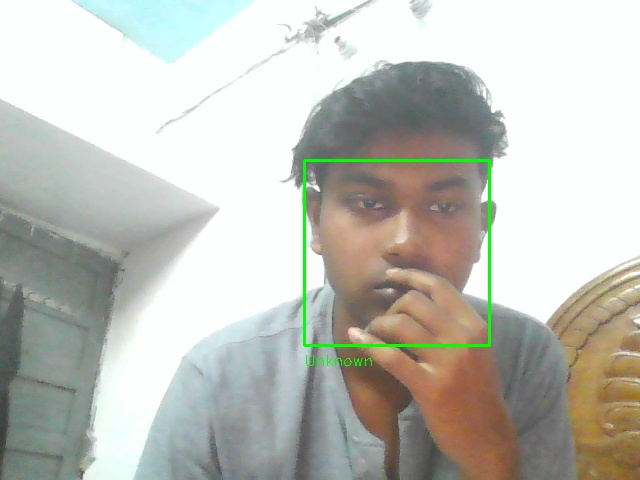

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1367: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvWaitKey'


In [10]:
import cv2
import face_recognition
import numpy as np
from IPython.display import display, clear_output, Image

# Load the reference photo (the person to verify against)
reference_image = face_recognition.load_image_file("reference_photo.jpg")
reference_face_encoding = face_recognition.face_encodings(reference_image)[0]

# Initialize the webcam
video_capture = cv2.VideoCapture(0)

def verify_face():
    while True:
        # Capture frame-by-frame
        ret, frame = video_capture.read()

        # Check if the frame was successfully captured
        if not ret:
            print("Error: Could not read frame from webcam.")
            break

        # Convert the frame from BGR to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Find all face locations and encodings in the frame
        face_locations = face_recognition.face_locations(rgb_frame)
        face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

        # Loop through each face found in the frame
        for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
            # Compare the face with the reference face
            matches = face_recognition.compare_faces([reference_face_encoding], face_encoding)
            name = "Unknown"

            # If a match is found, label the face as "Verified"
            if matches[0]:
                name = "Verified"

            # Draw a rectangle around the face
            cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)

            # Draw a label with the name below the face
            cv2.putText(frame, name, (left, bottom + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        # Display the resulting frame
        clear_output(wait=True)
        display(Image(data=cv2.imencode('.jpg', frame)[1].tobytes()))

        # Press 's' to exit
        if cv2.waitKey(1) & 0xFF == ord('s'):
            break

# Run the face verification function
verify_face()

# Release the webcam
video_capture.release()

In [3]:
!where python

C:\Users\DELL\jupyter_venv\Scripts\python.exe
C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\python.exe
C:\Users\DELL\AppData\Local\Programs\Python\Python313\python.exe


In [5]:
!pip install opencv-python

In [6]:
!pip install opencv-python-headless

   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.4 MB ? eta -:--:--
    --------------------------------------- 0.8/39.4 MB 1.9 MB/s eta 0:00:21
   - -------------------------------------- 1.3/39.4 MB 2.1 MB/s eta 0:00:19
   - -------------------------------------- 1.8/39.4 MB 2.1 MB/s eta 0:00:18
   -- ------------------------------------- 2.4/39.4 MB 2.3 MB/s eta 0:00:17
   -- ------------------------------------- 2.9/39.4 MB 2.4 MB/s eta 0:00:16
   --- ------------------------------------ 3.4/39.4 MB 2.4 MB/s eta 0:00:15
   --- ------------------------------------ 3.9/39.4 MB 2.5 MB/s eta 0:00:15
   ---- ----------------------------------- 4.5/39.4 MB 2.4 MB/s eta 0:00:15
   ----- ---------------------------------- 5.0/39.4 MB 2.4 MB/s eta 0:00:15
   ----- ---------------------------------- 5.5/39.4 MB 2.4 MB/s eta 0:00:15
   ----- -----------

In [1]:
import cv2
print(cv2.__version__)

4.11.0


In [2]:
!pip install face_recognition

  Using cached face_recognition-1.3.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached face_recognition_models-0.3.0-py2.py3-none-any.whl
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached pillow-11.1.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
Using cached face_recognition-1.3.0-py2.py3-none-any.whl (15 kB)
Using cached click-8.1.8-py3-none-any.whl (98 kB)
Using cached pillow-11.1.0-cp313-cp313-win_amd64.whl (2.6 MB)


In [ ]:
!pip uninstall opencv-python

In [2]:
!pip install ipywidgets

In [1]:
!pip install opencv-python